In [1]:
import os
from spectral.io import envi
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

import sys
sys.path.append('/store/carroll/repos/chess-isofit/')
from utilities import viz_rfl_subset

from isoplots import plots
import xarray as xr

import rasterio
from rasterio.transform import array_bounds
from rasterio.plot import show
from rasterio.plot import plotting_extent

%matplotlib widget

os.chdir('/store/carroll/col/data/')

In [6]:
out_figs = '/store/carroll/col/figs/'

wl = np.loadtxt('wavelengths_neon.txt')[:,1]*1000
wl_nan = np.loadtxt('wl_nan.txt')

rccs = np.loadtxt('2018/rccs/rcc_white_tarp_mean_6c_processed_20260107.txt')

fids = ['NIS01_20180620_162340', 'NIS01_20180619_162542', 'NIS01_20180612_155442']

In [57]:
n_sample = 10

rfls = []

for fid in fids:
    working_dir = f'2018/deploy_6c_20260109/{fid}_dsm_smooth_91'
    fp = glob(os.path.join(working_dir, 'output', '*_rfl.hdr'))[0]
    rfl = envi.open(fp)
    rows = np.random.randint(0, rfl.nrows, size=n_sample)
    cols = np.random.randint(0, rfl.ncols, size=n_sample)
    rfl = rfl.open_memmap()[rows,cols,:]
    rfls.append(rfl)
rfls = np.vstack(rfls)

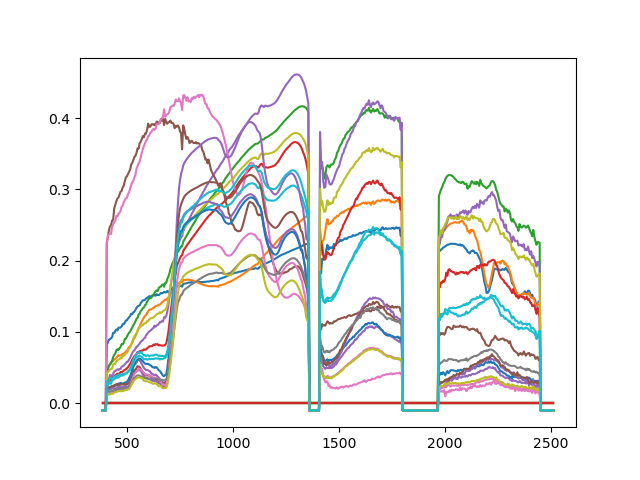

In [58]:
fig = plt.figure()
plt.plot(wl, rfls.T)
plt.show()

In [49]:
exp_arr = np.array((range(2, 426, 5)))
exp_arr.shape

(85,)

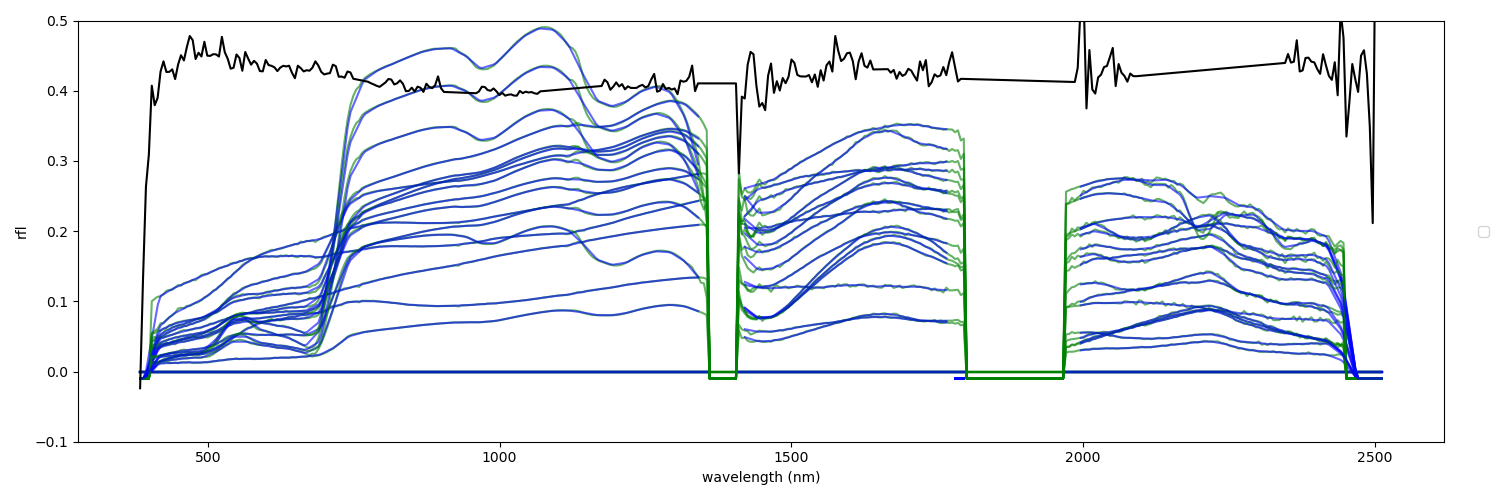

In [52]:
# set up rcc rfl interpolation

exp_arr = np.array((range(2, 426, 5)))
# exp_arr = np.array([2,5,10,13,20,27,37,42,50,60,75,85,100,150,180,190,206,210,220,235,250,260,270,279,320,340,350,356,364,368,375,380,385,392,400,405,410,415,420,425])

bin_size = 2
exp_lis = [np.mean(wl_nan[x-bin_size:x+bin_size]) for x in exp_arr]

fig = plt.figure(figsize=(15,5))

for i in range(rfls.shape[0]):
    rfl = rfls[i,:]
    plt.plot(wl, rfl, alpha=0.6, color='green')
    rfl_lis = [np.mean(rfl[x-bin_size:x+bin_size]) for x in exp_arr]
    interp = np.interp(wl_nan, exp_lis, rfl_lis)
    plt.plot(wl_nan, interp, alpha=0.6, color='blue')

plt.plot(wl, rccs-0.6, color='black')

plt.ylabel('rfl')
plt.xlabel('wavelength (nm)')

plt.ylim(-0.1, 0.5)

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()

plt.show()

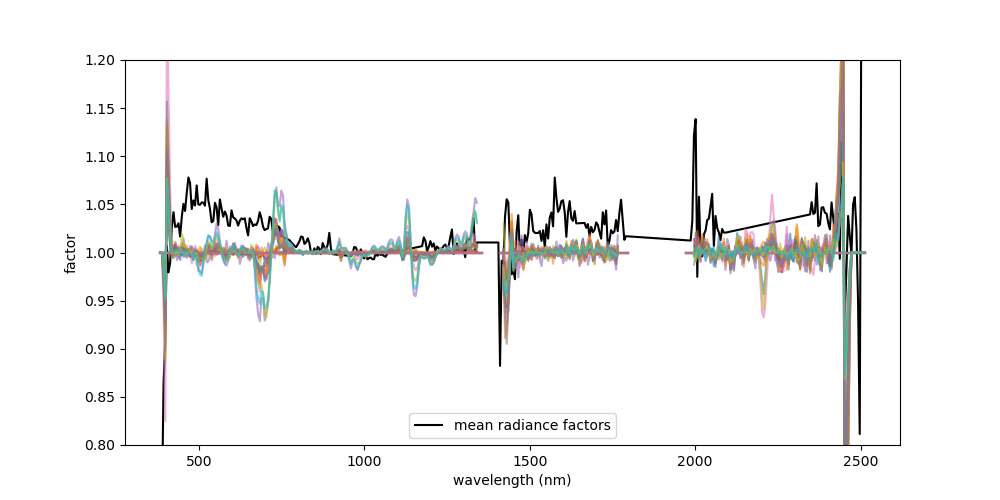

In [54]:
## from Phil - 

# visualize the delta between x_alg (from the rcc-adjusted rdn) and a smoothed linear interpolation of x_alg
# compare those deltas w/ rccs, across all bright/dark targets
# regions where the noise (deltas) are similar across targets and follow the trends of the rccs = regions we want to interpolate across

deltas = []

fig = plt.figure(figsize=(10,5))

exp_arr = np.array((range(2, 426, 5)))
# exp_arr = np.array([2,5,10,13,20,27,37,42,50,60,75,85,100,150,180,190,206,210,220,235,250,260,270,279,320,340,350,356,364,368,375,380,385,392,400,405,410,415,420,425])
bin_size = 2
exp_lis = [np.mean(wl_nan[x-bin_size:x+bin_size]) for x in exp_arr]

plt.plot(wl, rccs, color='black', label='mean radiance factors')

for i in range(rfls.shape[0]):
    rfl = rfls[i,:]
    rfl_lis = [np.mean(rfl[x-bin_size:x+bin_size]) for x in exp_arr]
    interp = np.interp(wl_nan, exp_lis, rfl_lis)
    delta = rfl - interp
    deltas.append(delta)
    plt.plot(wl_nan, delta*5+1, alpha=0.6)
    
plt.ylabel('factor')
plt.xlabel('wavelength (nm)')
plt.ylim(0.8, 1.2)
plt.legend()
plt.show()